<a href="https://colab.research.google.com/github/vanislekahuna/wps-labs/blob/main/Bayesian_Wildfire_Stats_Lab/%5BPart_1%5DRethinking_Predictors_Why_Causal_Reasoning_Matters_in_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Rethinking Predictors: Why Causal Reasoning Matters in Data Science (Part 1)**

<img src="https://images.unsplash.com/photo-1750096319146-6310519b5af2?q=80&w=764&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" width=548 height=686>


[Source](https://unsplash.com/photos/glowing-eyes-emanate-from-a-digital-face-EYm7NP5KsZw?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText)


## **Introduction**

Most of us entered data science through the front door of predictive accuracy where we learned to split our data, tune our models, and chase metrics. What we were taught less often is that a model can be simultaneously accurate and deeply misleading not because something went wrong technically, but because we never stopped to ask what was actually driving the outcome we were trying to predict. In this article, we want to build the case for a more deliberate approach to modelling, one rooted in the core ideas of causal reasoning.

To do these ideas justice, this article is going to be Part 1 of a two-part series where we introduce the core ideas behind causal reasoning and why adopting this framework of thinking could change the way you approach every analysis. Here we will focus on the theory, working through the key concepts that motivate a more causal way of thinking about our data and models. We'll also introduce ideas like data generating processes, multicollinearity, confounding variables, and spurious correlations, before using multiple linear regression as our primary lens for understanding them. In Part 2 we will put these ideas to work in a hands-on, more notebook style of learning where we apply these concepts to a real dataset and discuss the rationale behind our actions in the analysis. If you'd prefer to jump straight to the code, feel free to start there and circle back here when the theory feels relevant. But if you're the kind of person who likes to understand the *why* before the *how*, you're in the right place. Let's get started.

In [ ]:
%%capture

## Install the following libraries if necessary:
# !pip install arviz==0.20.0
# !pip install matplotlib==3.8.0
# !pip install pandas==2.2.2
# !pip install pymc==5.19.1
# !pip install scipy==1.13.1

In [ ]:
import requests
import sqlite3
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import pandas as pd
import pymc as pm
import seaborn as sns
import scipy.stats as stats

from matplotlib.patches import FancyArrowPatch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from pathlib import Path
from typing import Optional, Tuple

## **Uncovering DGP**

Within the data science and machine learning domain, it’s an open secret now that having richer, more high quality data often beats modelling or architectural choices (Halevy et al., 2009). In other words, applying a simple model to a rich dataset will lead to better predictive accuracy than a highly sophisticated model trained on a sparse dataset. This isn’t because the models don’t matter - they do - but because no amount of architectural elegance can conjure a signal that isn’t in your data. While optimizing for predictive accuracy is defensible under time and business constraints, I’d argue that mission-critical problems warrant a slower, more deliberate approach that requires establishing a causal understanding of the variable of interest. In other words, we want to move beyond asking what predicts our outcome and start asking *how* our outcomes were generated, understanding not just that two variables are associated, but that one actually *causes* a change in the other. This is the central question of **causal inference**.

If we veer slightly into the realm of philosophy, we can think of any phenomenon that produces observable data as a **data generating process (DGP)** which represents the *true* underlying mechanism by which the data arises from. In a typical data science project, a machine learning model attempts to approximate the input-output mapping well enough to make predictions. But in explicitly reasoning about the causal mechanisms behind the DGP, we’re thinking more like a physicist that’s less concerned with predicting where the ball will land, and more concerned with deriving the laws of motion that sent it there. Since DGP typically involves randomness and uncertainty, as data scientists or Bayesian statisticians, we attempt to approximate or describe this underlying mechanism using probability distributions. In practice, a DGP may actually be characterized by a single probability distribution or a complex combination of them with which we use tools like statistical models to try to understand and re-simulate this mechanism.

To use a simple analogy, the amount of pushups you can do in one go likely varies by the day. Some days you’re tired or sore, thereby reducing the number you can do. Other days you feel amazing and find you can do more than what you typically do. The main point is that in this analogy, we ourselves are the DGP for the outcome we’re measuring, which is really our physical prowess that’s proxied by the amount of pushups we can do in one go. We can think of our pushup count as a probability distribution which hovers around some individual mean that I strongly suspect is characterized as a tight bell curve (i.e. a Normal/Gaussian distribution). The same principle applies to the temperature in your city or household spending on housing. If you can measure it, there’s a data generating process behind it.

<img src="https://images.unsplash.com/photo-1667496778458-90122b6a5abb?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" width=878 height=585>

[Source](https://unsplash.com/photos/a-woman-doing-yoga-3pn26aY1Ygo?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText)

While it would be ideal to understand a target variable’s DGP to generate true causal understanding, doing so runs counterintuitive to our instinct as data scientists to maximise predictive accuracy because it tempts us into adding more predictors than are necessary. More predictors mean more complexity, and more complexity makes it harder to isolate the true causes, especially when some of those additions are merely correlating with the outcome rather than driving it. In other words, chasing accuracy in the short term risks sacrificing the very thing that makes a model useful in the long run, which is its ability to generalise beyond the dataset it was trained on.

If you found that was a lot to unpack, let’s jump back to our pushup analogy with the goal of building a model that can predict our *pushup count* in the future. If we used a high-quality predictor like *hours of sleep*, it alone may be enough to give us a good understanding for one of the main causes behind our target variable: *pushup count*. On the other hand, if we added a range of other variables such as our *energy* and *cortisol levels (a stress hormone)*, these additions may lead to a more accurate model. However, they may also muddy the signal because these additions are <u>symptoms</u> to the underlying causes rather than being the causes themselves. Conceptually, this is what’s known as a mediator in the causal reasoning space. More on that later.

For now, the main idea is that poor *sleep* elevates *cortisol levels* which suppresses physical performance, a result that’s well-documented in the literature. In other words, sleep has a **negative** or an **inverse relationship** with cortisol where if the opposite happens and you had more sleep, then you should be less stressed therefore your cortisol levels are reduced. On the other hand, sleep and energy have a **positive** or a **direct relationship** where both variables are tied together directionally. If you have less *sleep* then you also have less *energy* which is a separate issue that lessens your pushup count. A model built this way is telling you less about the world you’re investigating and more about the specific dataset it was trained on which will lead to problems of model generalization and adapting to dynamic circumstances.

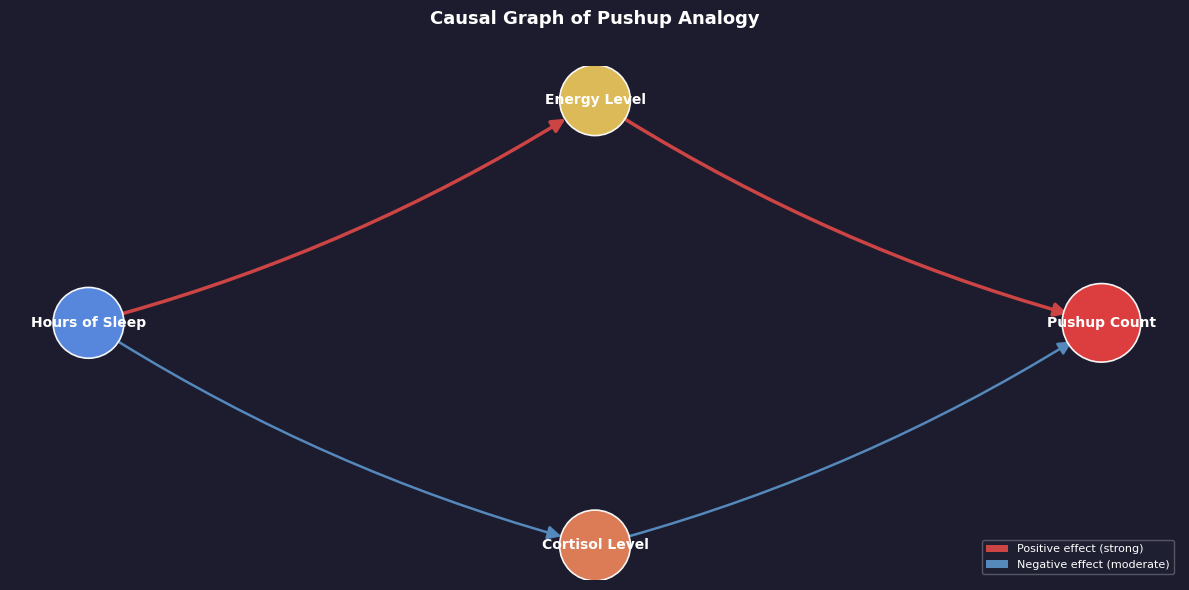

In [ ]:
G = nx.DiGraph()

exogenous = ["Hours of Sleep"]
mediators = ["Energy Level", "Cortisol Level"]
outcome   = ["Pushup Count"]

all_nodes = exogenous + mediators + outcome
G.add_nodes_from(all_nodes)

edges = [
    ("Hours of Sleep", "Energy Level",  "+", "strong"),
    ("Hours of Sleep", "Cortisol Level", "-", "moderate"),
    ("Energy Level",   "Pushup Count",  "+", "strong"),
    ("Cortisol Level", "Pushup Count",  "-", "moderate"),
]

for src, tgt, sign, strength in edges:
    G.add_edge(src, tgt, sign=sign, strength=strength)

pos = {
    "Hours of Sleep": (0.0,  0.50),
    "Energy Level":   (0.50, 0.75),
    "Cortisol Level": (0.50, 0.25),
    "Pushup Count":   (1.0,  0.50),
}

node_colours = {
    "Hours of Sleep": "#5A8EE8",
    "Energy Level":   "#E8C45A",
    "Cortisol Level": "#E8825A",
    "Pushup Count":   "#E84040",
}

edge_colours = {
    ("+", "strong"):   "#CC4444",
    ("+", "moderate"): "#CC7733",
    ("-", "strong"):   "#3366CC",
    ("-", "moderate"): "#5588BB",
}

edge_widths = {"strong": 2.5, "moderate": 1.8}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#1C1C2E")
ax.set_facecolor("#1C1C2E")

nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=[3200 if n == "Pushup Count" else 2600 for n in G.nodes()],
    node_color=[node_colours[n] for n in G.nodes()],
    edgecolors="#FFFFFF", linewidths=1.2,
    alpha=0.95,
)

for src, tgt, data in G.edges(data=True):
    sign     = data["sign"]
    strength = data["strength"]
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=[(src, tgt)],
        edge_color=edge_colours[(sign, strength)],
        style="solid",
        width=edge_widths[strength],
        arrows=True,
        arrowstyle="-|>",
        arrowsize=20,
        connectionstyle="arc3,rad=0.08",
        min_source_margin=25,
        min_target_margin=25,
    )

nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=10,
    font_color="#FFFFFF",
    font_weight="bold",
)

legend_elements = [
    mpatches.Patch(facecolor="#CC4444", label="Positive effect (strong)"),
    mpatches.Patch(facecolor="#5588BB", label="Negative effect (moderate)"),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=8,
    framealpha=0.25,
    facecolor="#2A2A40",
    edgecolor="#FFFFFF",
    labelcolor="#FFFFFF",
)


ax.set_title(
    "Causal Graph of Pushup Analogy",
    color="#FFFFFF", fontsize=13, fontweight="bold", pad=30,
)
ax.axis("off")
plt.tight_layout()

The presence of these ‘symptomatic’ predictors in a complex predictive model can introduce **multicollinearity** when two or more variables, symptomatic, causal or otherwise, are strongly correlated with each other, thus making it difficult to parse their contributions (McElreath, 2020). It’s like using the length of both a person’s legs to predict their height when using one will simply do. Among its many uses, multiple linear regression is particularly valuable here not for its ability to solve multicollinearity, but for its ability to separate the contributions of each predictor to the final prediction by holding the others constant. Rather than examining each predictor's relationship with the target variable in isolation, a **multiple linear regression** model allows us to measure the effect of each predictor simultaneously while controlling for the others. This makes it far better at distinguishing genuine associations from spurious ones, and at revealing relationships that might otherwise be masked.

Systematically deciding which predictors we include in our regression models can expose **spurious correlation** which is an association between two variables that disappears once we account for a confounding variable (McElreath, 2020). And in case we need to jog our memory for statistical jargon, a **confounding variable** is a third variable that independently influences both the predictor and the outcome, thus creating a false appearance of a direct relationship between them (McElreath, 2020). Multiple linear regression models help us uncover masked correlations that only become visible once a confounding variable is held constant.

## **Reasoning about wildfires**

Now that we’re armed with the theory, let’s sharpen these ideas by re-visiting our [previous article](https://medium.com/towards-artificial-intelligence/playing-with-fire-and-priors-learning-the-limits-of-bayesian-linear-regression-with-pymc-1897962c25c5) where we attempted to model wildfire size (i.e. the amount of hectares burnt in a wildfire) for incidents across the Canadian province of British Columbia. Despite our initial research into the factors that determine wildfire spread (remember the [fire triangle](https://medium.com/r/?url=https%3A%2F%2Fwww2.gov.bc.ca%2Fgov%2Fcontent%2Fsafety%2Fwildfire-status%2Fwildfire-response%2Fabout-wildfire) here), in practice we learned that wind speed alone was actually a poor predictor of its overall size simply because of the enormous complexity governing how far a fire spreads before it’s eventually put out. <mark>If we want to improve our model’s predictive capability, the best option would be to <u>engineer a rich dataset</u> around human variables, such as response times and fire hall distances, or the geography of the surrounding area.</mark>

However in this instance, wildfire size is precisely the kind of target variable where a causal understanding pays dividends beyond prediction. If we know what actually drives fire spread, that knowledge can directly inform government policy and resource allocation decisions before a fire ever starts. Unfortunately doing this research properly is beyond the time, resources, and bandwidth that we have available to us. However, we can still extract real value from this exercise by approximating this process of causal thinking. Having already used wind speed as a predictor, this time around let’s add more atmospheric predictors to our analysis with the aim of understanding the causal structure behind their influence on wildfire size. Note that in this section, we’ll introduce the atmospheric predictors in our analysis and discuss our hypothesis of how they may be causally linked to the fire sizes we observe in our dataset. Our hypothesis will be represented as relationships in a causal graph which we’ll then interrogate in Part 2 using multiple linear regression.

In [ ]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 824
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89  # sets default credible interval used by arviz

/usr/local/lib/python3.12/dist-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


### **Data Extraction (SQLite)**

To ground these ideas, let's bring in the dataset we'll be working with throughout this series which is the wildfire dataset we previously engineered using through the open source data at the BC Data Catalogue and through Google’s Earth Engine API. If you’re interested in the details behind that, feel free to check out the [article](https://medium.com/towards-artificial-intelligence/how-to-augment-wildfire-datasets-with-historical-weather-data-using-python-and-google-earth-engine-eae4c2a73650) we wrote documenting the process:

In [ ]:
db_link = "https://raw.githubusercontent.com/vanislekahuna/wps-labs/main/data/historical_bc_wildfires/bc_wildfires.db"
response = requests.get(db_link)
with open("bc_wildfires.db", "wb") as f:
    f.write(response.content)

conn = sqlite3.connect('bc_wildfires.db')
cursor = conn.cursor()

In [ ]:
join_query = """
WITH weather AS (
    SELECT wind_speed_ms, wind_direction_deg, wind_direction, temperature_c AS temp_c_ign_date, humidity_dewpoint_temperature_2m AS humidity_dewpoint_temp_k_ign_date, soil_temperature_level_1 AS soil_temp_lvl1_ign_date, fire_label AS weather_fire_label
    FROM weather_data
),
terraclimate AS (
    SELECT monthly_mean_temp_c, monthly_total_precip_mm, monthly_mean_humidity_vpd_kPa, monthly_mean_soil_moisture_mm, fire_label AS terraclimate_fire_label
    FROM terraclimate_bc_weather
)
SELECT *
FROM historical_bc_wildfires
LEFT JOIN weather ON historical_bc_wildfires.FIRELABEL = weather.weather_fire_label
LEFT JOIN terraclimate ON historical_bc_wildfires.FIRELABEL = terraclimate.terraclimate_fire_label
WHERE historical_bc_wildfires.SIZE_HA IS NOT NULL
AND historical_bc_wildfires.SIZE_HA > 0
AND historical_bc_wildfires.FIRELABEL NOT IN ('1951-R00037', '1951-R00050', '1951-R00060', '1951-R00067', '1951-R00069', '1951-R00070', '1956-R00107', '1958-V00283', '1956-R00160', '1968-R00088', '1985-V70083', '1985-V70088', '1987-V90016', '1990-V50012');
"""

df = pd.read_sql_query(join_query, conn)

print(f"DataFrame shape: {df.shape} \n\n \
Columns: {df.columns} \n")

df.head()

DataFrame shape: (162905, 33) 

 Columns: Index(['FIRE_NO', 'FIRE_YEAR', 'RSPNS_TYPC', 'IGN_DATE', 'FR_T_DTE',
       'FIRE_CAUSE', 'FIRELABEL', 'FRCNTR', 'ZONE', 'FIRE_ID', 'FIRE_TYPE',
       'INCDNT_NM', 'GEO_DESC', 'LATITUDE', 'LONGITUDE', 'SIZE_HA', 'FCODE',
       'SHAPE', 'OBJECTID', 'X_COORDINATE', 'Y_COORDINATE', 'wind_speed_ms',
       'wind_direction_deg', 'wind_direction', 'temp_c_ign_date',
       'humidity_dewpoint_temp_k_ign_date', 'soil_temp_lvl1_ign_date',
       'weather_fire_label', 'monthly_mean_temp_c', 'monthly_total_precip_mm',
       'monthly_mean_humidity_vpd_kPa', 'monthly_mean_soil_moisture_mm',
       'terraclimate_fire_label'],
      dtype='object') 



,FIRE_NO,FIRE_YEAR,RSPNS_TYPC,IGN_DATE,FR_T_DTE,FIRE_CAUSE,FIRELABEL,FRCNTR,ZONE,FIRE_ID,...,wind_direction,temp_c_ign_date,humidity_dewpoint_temp_k_ign_date,soil_temp_lvl1_ign_date,weather_fire_label,monthly_mean_temp_c,monthly_total_precip_mm,monthly_mean_humidity_vpd_kPa,monthly_mean_soil_moisture_mm,terraclimate_fire_label
0,V11082,2021,Full,2.021063e+13,2.021063e+13,Person,2021-V11082,2.0,1.0,1082,...,Northwest,24.190454,288.407013,293.928192,2021-V11082,13.90,33.0,82.0,662.0,2021-V11082
1,K50948,2020,Full,2.020080e+13,2.020081e+13,Person,2020-K50948,5.0,5.0,500948,...,East,26.581812,279.547333,296.103882,2020-K50948,18.75,11.0,133.0,182.0,2020-K50948
2,V70735,2021,Full,2.021061e+13,2.021061e+13,Person,2021-V70735,2.0,7.0,735,...,West,14.023950,278.705872,288.122131,2021-V70735,18.00,33.0,78.0,509.0,2021-V70735
3,K20928,2021,Full,2.021063e+13,2.021063e+13,Person,2021-K20928,5.0,2.0,928,...,Northwest,16.139764,282.903931,288.909363,2021-K20928,14.80,23.0,103.0,296.0,2021-K20928
4,V81001,2022,Full,2.022080e+13,2.022080e+13,Person,2022-V81001,2.0,8.0,1001,...,Northwest,13.016840,282.843109,288.308258,2022-V81001,17.70,45.0,60.0,355.0,2022-V81001


In [ ]:
wildfire_df = df[
    [
        "FRCNTR",
        "FIRELABEL",
        "IGN_DATE",
        "FIRE_CAUSE",
        "SIZE_HA",
        "wind_speed_ms",
        "temp_c_ign_date",
        "humidity_dewpoint_temp_k_ign_date",
        "soil_temp_lvl1_ign_date",
        "monthly_mean_temp_c",
        "monthly_total_precip_mm",
        "monthly_mean_humidity_vpd_kPa",
        "monthly_mean_soil_moisture_mm"
    ]
  ].copy()

In [ ]:
centres = wildfire_df["FRCNTR"].unique()

### Exploratory Data Analysis & Feature Engineering

#### Log Transformations


And just like [before](https://medium.com/towards-artificial-intelligence/playing-with-fire-and-priors-learning-the-limits-of-bayesian-linear-regression-with-pymc-1897962c25c5), we’ll be transforming our wind speed predictor and our fire size target variable into logarithmic scale due to the high deviation in these variables’ probability distributions. The result of the transformation ends up being a Gaussian distribution. We’ll also convert the values in the `soil_temp_lvl1_ign_date` variable from Kelvin to Celsius by subtracting `273.15` from each value.

In [ ]:
wildfire_df["size_log1ptransformed"] = np.log1p(wildfire_df["SIZE_HA"])
wildfire_df["wind_speed_log1ptransformed"] = np.log1p(wildfire_df["wind_speed_ms"])
wildfire_df["soil_temp_c_lvl1_ign_date"] = wildfire_df["soil_temp_lvl1_ign_date"] - 273.15

print(f"wildfire_df shape: {wildfire_df.shape} \n")

wildfire_df shape: (162905, 16) 



#### One-Hot Encodding

Finally, we'll encode the **categorical variable**, `FIRE_CAUSE`, containing three discrete, unordered values — *lightning, person*, and *unknown* — representing the identified cause of each fire in the dataset as separate numeric predictors. To incorporate these into a model numerically, we'll apply the process known as **one-hot encoding** to the lightning and person categories by creating a dedicated binary column for each one where a `1` indicates the category is present while a `0` indicates it is not. When both columns contain a `0`, the cause is implicitly *unknown* given it’s the only remaining option which makes an explicit *unknown* predictor redundant and can therefore be safely omitted from the model.

In [ ]:
print(wildfire_df["FIRE_CAUSE"].value_counts())
one_hot_encodding = pd.get_dummies(wildfire_df["FIRE_CAUSE"], dtype=int)

FIRE_CAUSE
Person       69290
Lightning    67667
Unknown      25948
Name: count, dtype: int64


In [ ]:
wildfire_df = pd.concat([wildfire_df, one_hot_encodding], axis=1)

print(f"wildfire_df shape: {wildfire_df.shape} \n")
wildfire_df.head()

wildfire_df shape: (162905, 19) 



,FRCNTR,FIRELABEL,IGN_DATE,FIRE_CAUSE,SIZE_HA,wind_speed_ms,temp_c_ign_date,humidity_dewpoint_temp_k_ign_date,soil_temp_lvl1_ign_date,monthly_mean_temp_c,monthly_total_precip_mm,monthly_mean_humidity_vpd_kPa,monthly_mean_soil_moisture_mm,size_log1ptransformed,wind_speed_log1ptransformed,soil_temp_c_lvl1_ign_date,Lightning,Person,Unknown
0,2.0,2021-V11082,2.021063e+13,Person,0.009,0.238463,24.190454,288.407013,293.928192,13.90,33.0,82.0,662.0,0.008960,0.213871,20.778192,0,1,0
1,5.0,2020-K50948,2.020080e+13,Person,0.240,0.702857,26.581812,279.547333,296.103882,18.75,11.0,133.0,182.0,0.215111,0.532308,22.953882,0,1,0
2,2.0,2021-V70735,2.021061e+13,Person,0.010,3.984139,14.023950,278.705872,288.122131,18.00,33.0,78.0,509.0,0.009950,1.606261,14.972131,0,1,0
3,5.0,2021-K20928,2.021063e+13,Person,0.009,2.504193,16.139764,282.903931,288.909363,14.80,23.0,103.0,296.0,0.008960,1.253960,15.759363,0,1,0
4,2.0,2022-V81001,2.022080e+13,Person,0.009,2.674716,13.016840,282.843109,288.308258,17.70,45.0,60.0,355.0,0.008960,1.301476,15.158258,0,1,0


#### Isolating Predictors and Target

Given the log transformations in our `wind_speed_log1ptransformed` predictor and `size_log1ptransformed` target variable, as well as the conversion of the `FIRE_CAUSE` column into dummy variables, let’s briefly discuss the other relevant predictors for our model. The `temp_c_ign_date` represents the measured surface temperature of the land at 2 metres above ground in Celsius while `soil_temp_c_lvl1_ign_date` is the measured surface temperature of the soil right on the surface. Both measurements were taken during the date when the fire was first recorded.

Other predictors include `monthly_total_precip_mm` which is the accumulated rainfall of the area (in millimetres) during the given month and `monthly_mean_humidity_vpd_kPa` which is a measure of the average atmospheric humidity of the area during the month when the fire was first observed. Another way to think about humidity as measured by VPD is that it’s a measure of how aggressively the atmosphere is pulling moisture out of its surroundings. Lastly, the `monthly_mean_soil_moisture_mm` column represents the average total soil moisture for the given month, measured in millimetres of water equivalent. It’s derived from [TerraClimate's](https://medium.com/r/?url=https%3A%2F%2Fdevelopers.google.com%2Fearth-engine%2Fdatasets%2Fcatalog%2FIDAHO_EPSCOR_TERRACLIMATE%23bands) water balance model which estimates the water retained in the soil after accounting for precipitation, evapotranspiration, and runoff.

In [ ]:
predictor_cols = [
    "wind_speed_log1ptransformed",
    "Lightning",
    "Person",
    "temp_c_ign_date",
    "soil_temp_c_lvl1_ign_date",
    "monthly_total_precip_mm",
    "monthly_mean_humidity_vpd_kPa",
    "monthly_mean_soil_moisture_mm"
  ]

target_col = "size_log1ptransformed"

Lastly and very importantly, since the vast majority of fires are small localized events that are contained quickly, the distribution of fire size is extremely right-skewed as displayed in [Figure 3](https://medium.com/r/?url=https%3A%2F%2Fpub.towardsai.net%2Fplaying-with-fire-and-priors-learning-the-limits-of-bayesian-linear-regression-with-pymc-1897962c25c5) of our previous article. Given the distribution, we’ll focus solely on large fires that had the opportunity to grow over 100 hectares to investigate the atmospheric conditions that led to this massive fire spread. By doing so, our dataset that was originally about 162k rows of data shrinks to about 4k rows which introduces a form of selection bias because then we’re only examining the atmospheric conditions present amongst fires that crossed our predetermined threshold.

> *Therefore our causal findings should be interpreted with care as they reflect the relationship between our atmospheric predictors and fires only within this population of large fires so they cannot be generalized across all BC wildfires.*

In [ ]:
large_fire_df = wildfire_df[wildfire_df['SIZE_HA'] >= 100].dropna()
print(large_fire_df.shape)

(3818, 19)


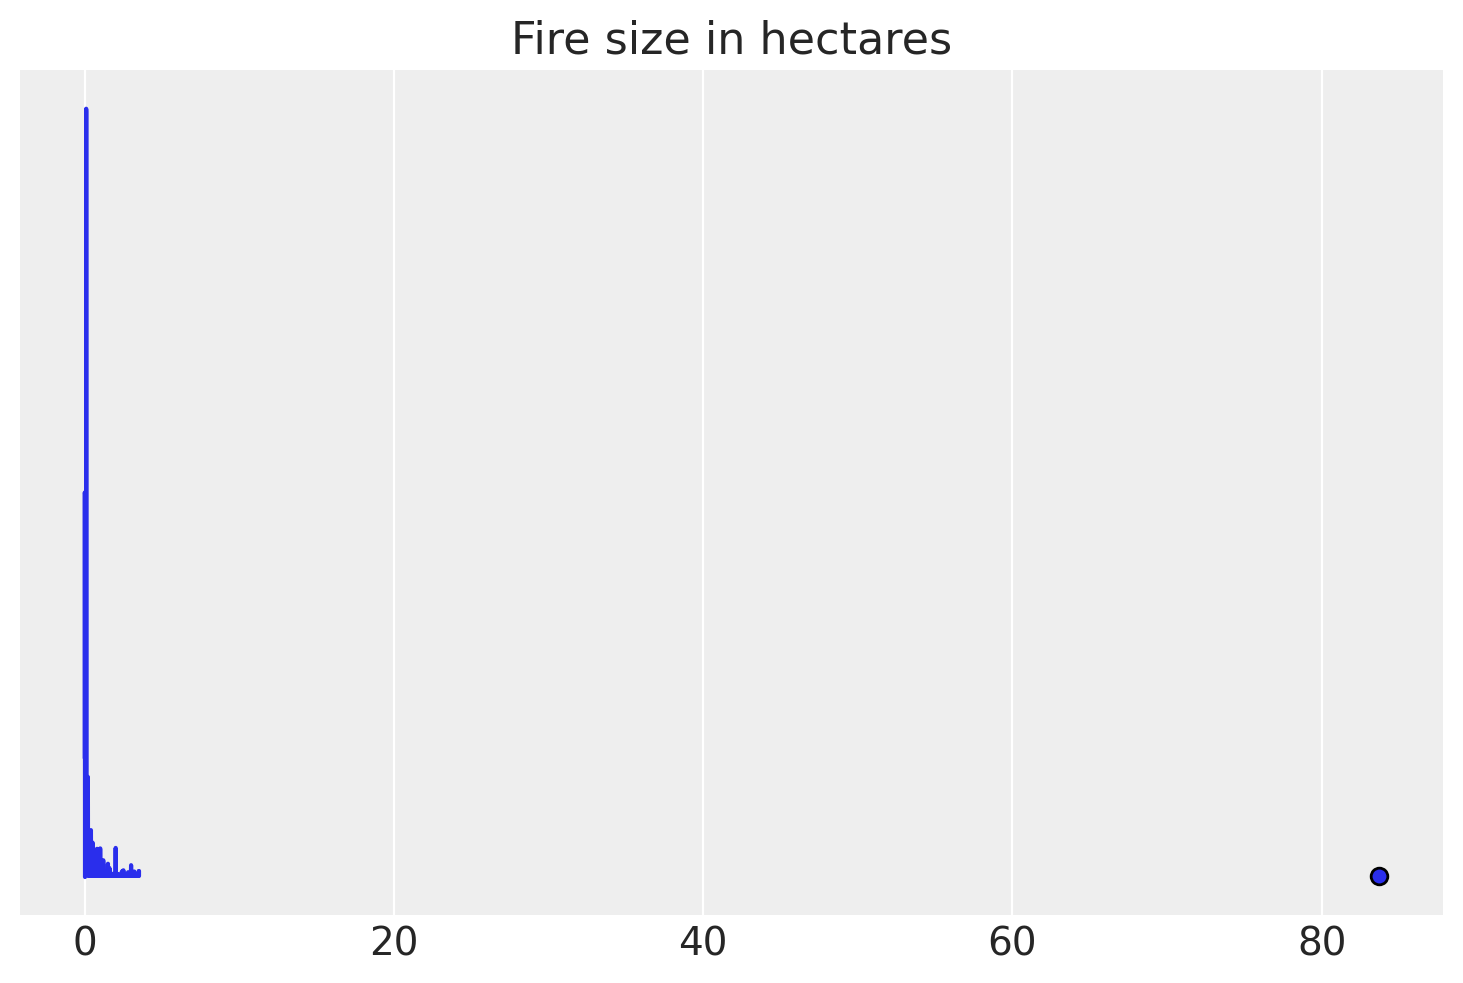

In [ ]:
az.plot_density(df["SIZE_HA"].to_numpy())
plt.title("Fire size in hectares")
plt.show()

## **Interpreting our Causal DAG**

Earlier in our pushup example, you’ll notice that we built a causal graph in *Figure 1* to qualitatively describe our hypothesis of the relationship that our three predictors (hours of sleep, energy levels, and cortisol levels) had with our target variable, pushup count. That causal graph is is known as a **Directed Acyclic Graph (DAG)** where essentially each word describes a characteristic of the causal relationship it's intended to describe:

1. **Directed** refers to the direction, or the flow, of the relationships in the causal structure. In our pushup example, we can see that the structure in this case flowed from left to right but DAGs can generally flow in any direction;
2. **Acyclic** means that the direction is one-directional and does not eventually flow back on itself. The opposite of this would be a cyclic graph often used to describe a feedback mechanism;
3. And the **graph** component simply describes the nodes (i.e. the variables of interest) and the directed edges (i.e. the arrows) representing the assumed causal relationships between them.

In the code below, let’s build another DAG using the variables in our fire size project to illustrate our hypothesis of the causal mechanisms behind the atmospheric predictors driving fire size. After that, we will discuss our reasoning behind the hypothesis which will segway nicely into Part 2 where we’ll then run certain tests to evaluate it.


/tmp/ipykernel_8506/2542002290.py:166: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


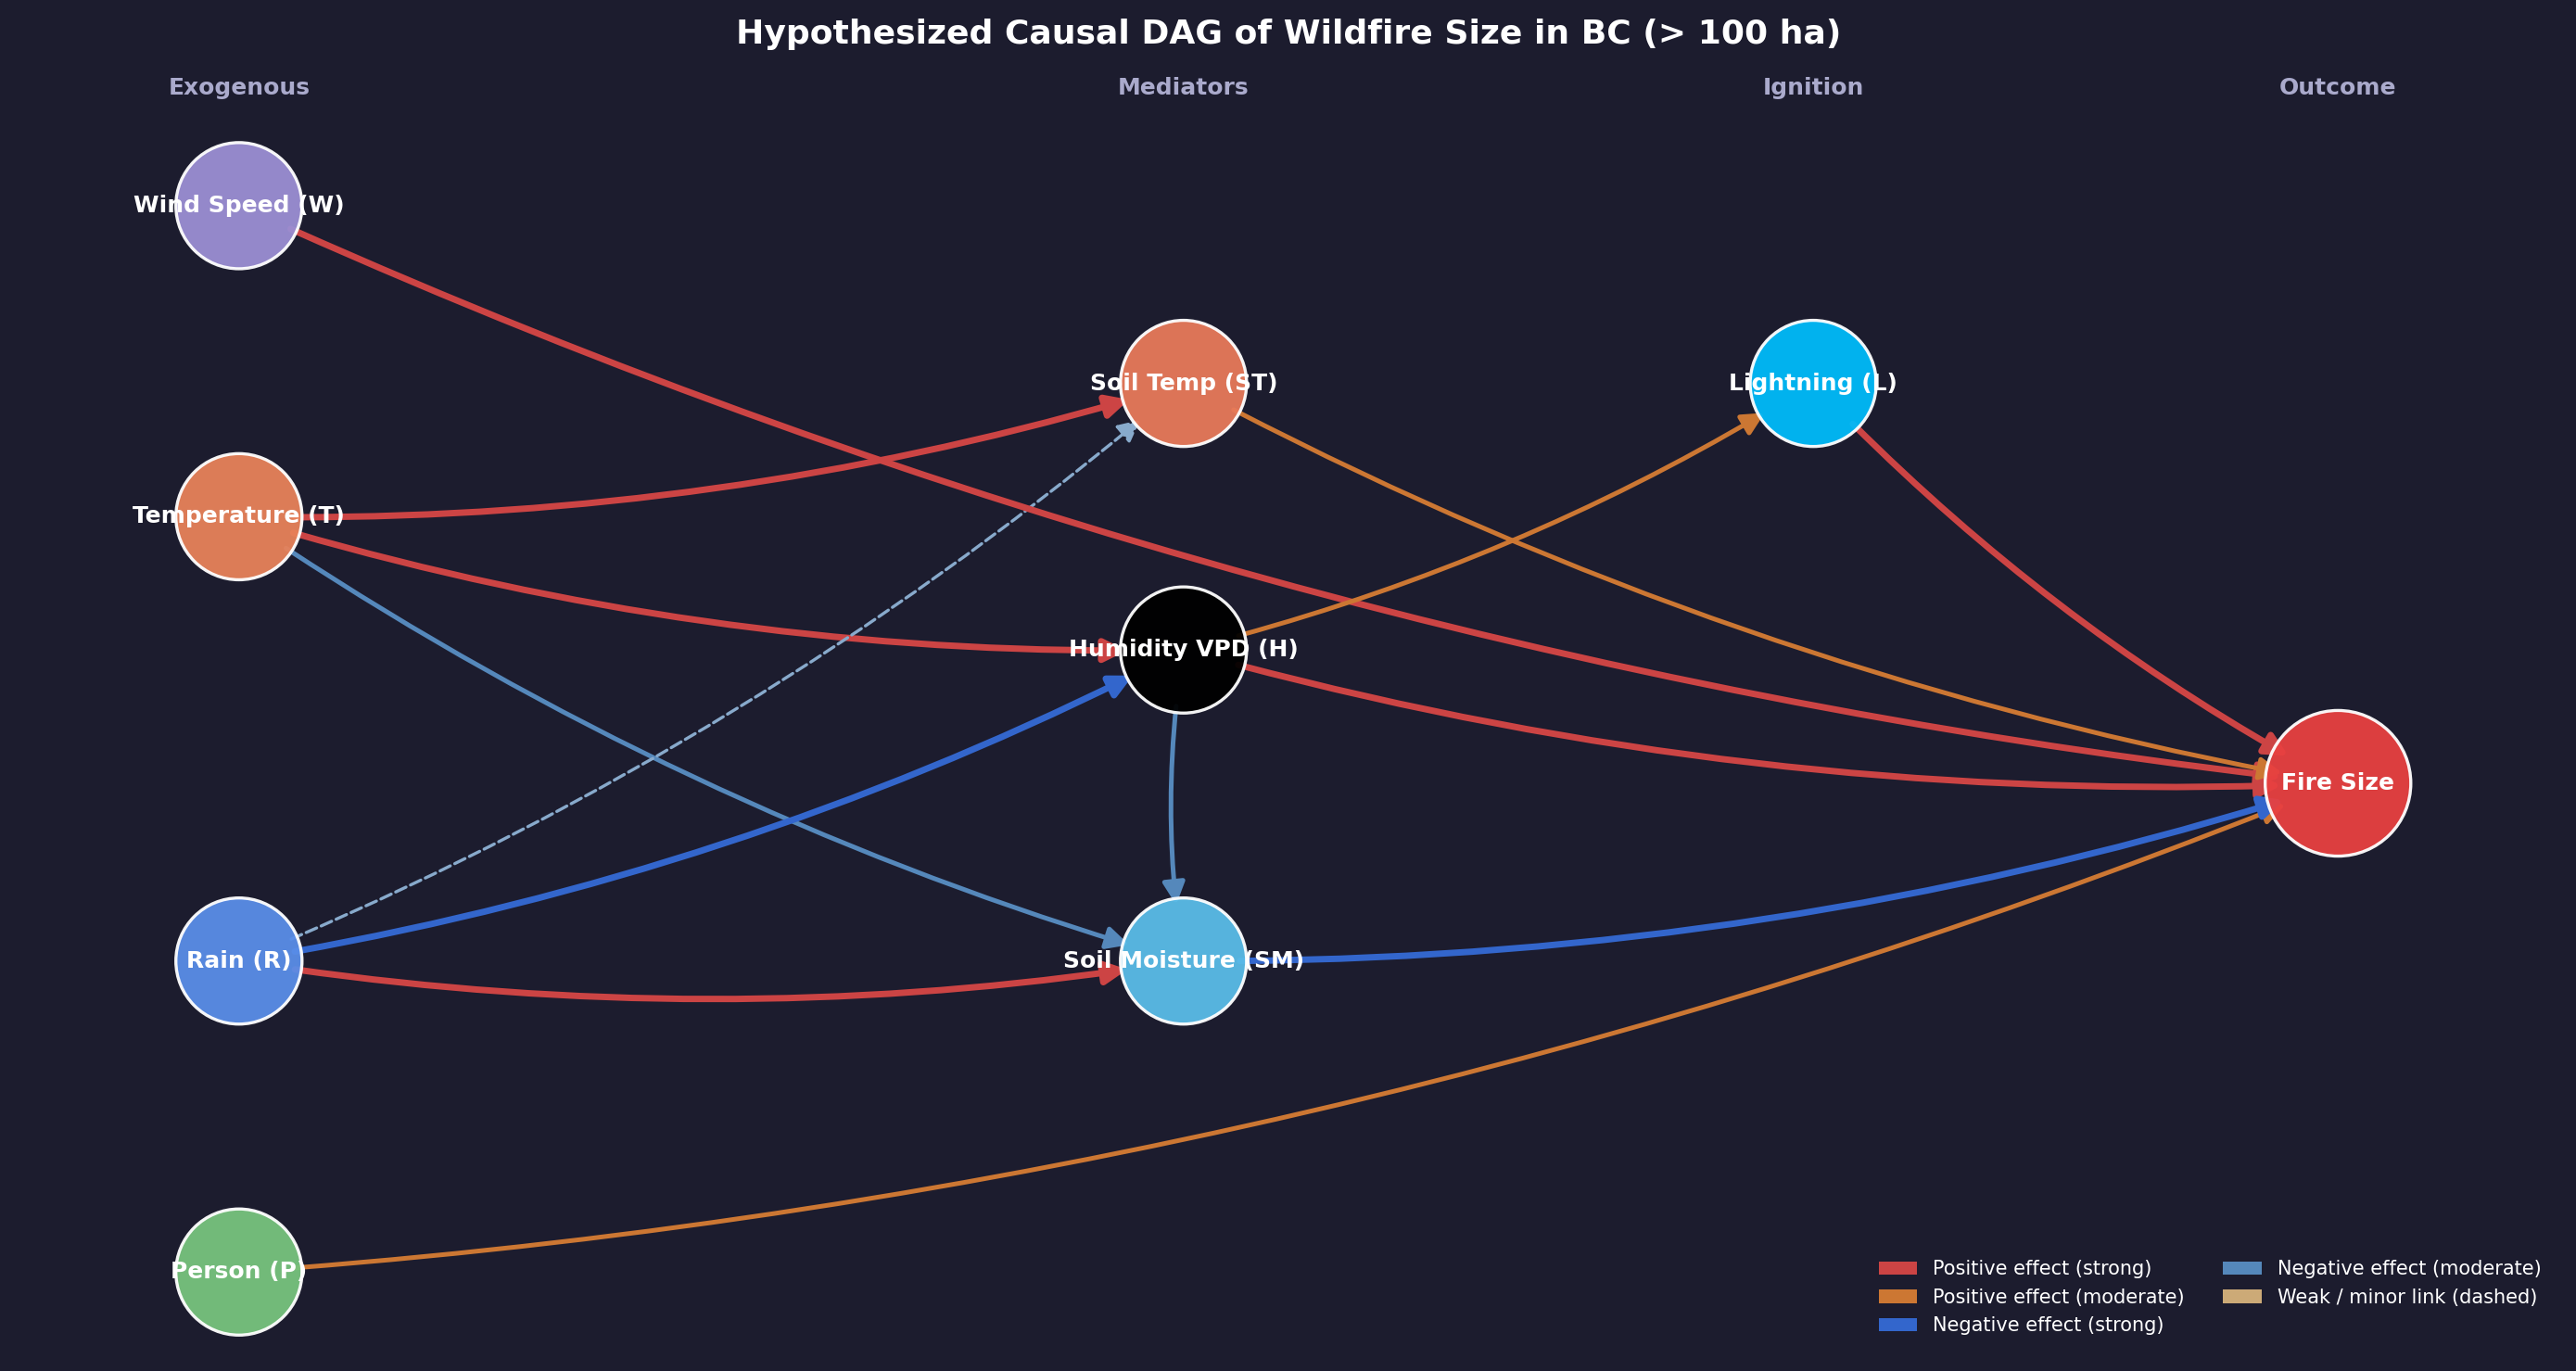

In [ ]:
# ── Build the DAG ─────────────────────────────────────────────────────────────
G = nx.DiGraph()

# Node groups
exogenous   = ["Temperature (T)", "Rain (R)", "Wind Speed (W)", "Person (P)"]
mediators   = ["Humidity VPD (H)", "Soil Moisture (SM)", "Soil Temp (ST)"]
ignition    = ["Lightning (L)"]
outcome     = ["Fire Size"]

all_nodes = exogenous + mediators + ignition + outcome
G.add_nodes_from(all_nodes)

# Edges: (source, target, sign, strength)
edges = [
    # Temperature pathways
    ("Temperature (T)",   "Humidity VPD (H)", "+", "strong"),
    ("Temperature (T)",   "Soil Temp (ST)","+", "strong"),
    ("Temperature (T)",   "Soil Moisture (SM)", "-", "moderate"),

    # Precipitation pathways
    ("Rain (R)", "Humidity VPD (H)", "-", "strong"),
    ("Rain (R)", "Soil Moisture (SM)",  "+", "strong"),
    ("Rain (R)", "Soil Temp (ST)","-", "weak"),

    # VPD downstream
    ("Humidity VPD (H)", "Soil Moisture (SM)",  "-", "moderate"),
    ("Humidity VPD (H)", "Lightning (L)",      "+", "moderate"),

    # Direct effects on Fire Size
    ("Wind Speed (W)",      "Fire Size",    "+", "strong"),
    ("Humidity VPD (H)", "Fire Size",    "+", "strong"),
    ("Soil Moisture (SM)",   "Fire Size",    "-", "strong"),
    ("Soil Temp (ST)","Fire Size",    "+", "moderate"),
    ("Lightning (L)",       "Fire Size",    "+", "strong"),
    ("Person (P)",          "Fire Size",    "+", "moderate"),
]

for src, tgt, sign, strength in edges:
    G.add_edge(src, tgt, sign=sign, strength=strength)

# ── Layout ────────────────────────────────────────────────────────────────────
# Manual positions for legibility
pos = {
    # Exogenous — left column
    "Temperature (T)":    (0.0, 0.75),
    "Rain (R)":  (0.0, 0.25),
    "Wind Speed (W)":     (0.0, 1.10),
    "Person (P)":         (0.0, -0.10),

    # Mediators — centre column
    "Humidity VPD (H)":            (0.45, 0.60),
    "Soil Moisture (SM)":  (0.45, 0.25),
    "Soil Temp (ST)":(0.45, 0.90),

    # Ignition — right-centre
    "Lightning (L)":      (0.75, 0.90),

    # Outcome — far right
    "Fire Size":      (1.0,  0.45),
}

# ── Colours & style ───────────────────────────────────────────────────────────
node_colours = {
    "Temperature (T)":     "#E8825A",
    "Rain (R)":            "#5A8EE8",
    "Wind Speed (W)":      "#9B8FD4",
    "Person (P)":          "#78C47E",
    "Humidity VPD (H)":    "#000000",
    "Soil Moisture (SM)":  "#5ABCE8",
    "Soil Temp (ST)":      "#E87A5A",
    "Lightning (L)":       "#00BBFA",
    "Fire Size":           "#E84040",
}

edge_colours = {
    ("+", "strong"):   "#CC4444",
    ("+", "moderate"): "#CC7733",
    ("+", "weak"):     "#CCAA77",
    ("-", "strong"):   "#3366CC",
    ("-", "moderate"): "#5588BB",
    ("-", "weak"):     "#88AACC",
}

edge_styles = {
    "strong":   "solid",
    "moderate": "solid",
    "weak":     "dashed",
}

edge_widths = {"strong": 2.5, "moderate": 1.8, "weak": 1.2}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7.5))
fig.patch.set_facecolor("#1C1C2E")
ax.set_facecolor("#1C1C2E")

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=[3200 if n == "Fire Size" else 2400 for n in G.nodes()],
    node_color=[node_colours[n] for n in G.nodes()],
    edgecolors="#FFFFFF", linewidths=1.2,
    alpha=0.95,
)

# Draw edges individually to control style
for src, tgt, data in G.edges(data=True):
    sign     = data["sign"]
    strength = data["strength"]
    colour   = edge_colours[(sign, strength)]
    style    = edge_styles[strength]
    width    = edge_widths[strength]

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=[(src, tgt)],
        edge_color=colour,
        style=style,
        width=width,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        connectionstyle="arc3,rad=0.08",
        min_source_margin=22,
        min_target_margin=22,
    )

# Labels
nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=9,
    font_color="#FFFFFF",
    font_weight="bold",
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor="#CC4444", label="Positive effect (strong)"),
    mpatches.Patch(facecolor="#CC7733", label="Positive effect (moderate)"),
    mpatches.Patch(facecolor="#3366CC", label="Negative effect (strong)"),
    mpatches.Patch(facecolor="#5588BB", label="Negative effect (moderate)"),
    mpatches.Patch(facecolor="#CCAA77", label="Weak / minor link (dashed)")
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=7.5,
    framealpha=0.25,
    facecolor="#2A2A40",
    edgecolor="#FFFFFF",
    labelcolor="#FFFFFF",
    ncol=2,
)

# Column annotations
for x, label in [(0.0, "Exogenous"), (0.45, "Mediators"), (0.75, "Ignition"), (1.0, "Outcome")]:
    ax.text(x, 1.22, label, ha="center", va="bottom", fontsize=9,
            color="#AAAACC", fontweight="bold", transform=ax.transData)

ax.set_title(
    "Hypothesized Causal DAG of Wildfire Size in BC (> 100 ha)",
    color="#FFFFFF", fontsize=13, fontweight="bold", pad=30,
)
ax.axis("off")
plt.tight_layout()

Ok we’ve specified our hypothesis of the mechanism driving our outcome through a causal DAG in *Figure 2*. Notice how our target variable, fire size, is positioned at the far right of our DAG and everything upstream of it is our attempt to answer a deceptively simple question: *what atmospheric conditions allowed a fire to grow beyond 100 hectares?*

Rather than treating our predictors as an interchangeable list of inputs, the DAG forces us to engage in causal reasoning and be explicit about how we think they are related to each other and to our target variable. If you think about it, this line of reasoning shares a similar spirit with how we specify priors in Bayesian models in that both require us to make our assumptions explicit before fitting to the data. Just as priors encode our beliefs about parameter values, DAGs encode our beliefs about causal structure.

The graph organises our variables into four structural layers. On the far left sits the layer we’ll term as “exogenous” variables which we treat as inputs that are not themselves caused by anything else in our system. These are temperature, rain, wind speed, and people-caused fires.

In the centre are the humidity VPD, soil moisture, and soil temperature variables we’ve categorized as mediators, a term we mentioned earlier in our pushup example. **Mediators** are variables that sit on the causal pathway between a cause and an outcome, transmitting some or all of that upstream influence forward. In doing so, mediators partially or fully account for why the relationship between cause and outcome exists at all.

Lightning occupies its own layer we’ll term as the “ignition” layer that’s positioned closer to the outcome because its role is more immediate in that it doesn't shape the environment the way temperature or rain can. However, it can directly trigger a fire given the right conditions. Lastly, fire size is the outcome layer that all pathways eventually feed into.

Now let's trace those pathways. Wind speed and person-caused fires take a more direct route to the outcome. We hypothesize that wind speed has a strong positive effect on fire size since wind dries fuel, supplies oxygen, and carries embers ahead of the fire front. Similarly, we also hypothesize that human-caused ignitions also have a direct positive link to fire size without any upstream dependencies and that neither of these variables influence any of the mediators in our system.

In atmospheric conditions that lead to humid environments, we hypothesize lightning may also have a strong positive effect on fire size when it’s the ignition source because it may have struck in remote areas where humans can’t as easily observe and report a fire. Therefore in reasoning about lightning, we may have uncovered a possible confounding variable which we could describe as “geographic isolation” or “inaccessibility.”

With higher temperatures, we hypothesize that it directly drives up humidity VPD and soil temperature, both of which we expect to positively influence fire size. At the same time, higher temperatures have an inverse relationship with soil moisture since heat accelerates evaporation and dries the land out. In turn, drier soil provides less natural resistance to fire spread. Temperature, in other words, is not just one predictor among many but a root cause that ripples through the entire system.

Opposite to temperature, rain has an inverse relationship across nearly every pathway it touches and has a dominant dampening force in the DAG. Precipitation suppresses humidity and soil temperature by adding moisture back into the atmosphere and cooling it. However, it has a positive relationship with soil moisture by replenishing the ground with water. Its absence during dry months is a key part of why large wildfires become possible in the first place.

Humidity VPD deserves particular attention because it sits at a kind of crossroads in our causal structure and therefore is one of the more structurally important variables in the graph. Since the atmospheric instability associated with hot, dry air is a known precondition for convective thunderstorms, humidity functions as both a mediator for half of our exogenous variables while also being a partial cause of ignition itself.

Mediators are worth examining rather closely because including them in a regression model can actually obscure the relationships we are trying to estimate (McElreath, 2020). For example if we include soil moisture alongside rain in the same model, we risk blocking or underestimating part of rain's causal effect on fire size because some of that effect has to travel through soil moisture. Essentially we need to ask ourselves: Is it necessary to include a measure of soil moisture if we already have data for rainfall? It is not a flaw in the data per se but a flaw in the reasoning behind the model specification.

## **Bridging to Part 2**

At the end of the day, it's worth being transparent about what this DAG is and what it’s not. Our DAG is a qualitative hypothesis, not a proven causal structure. The arrows and signs represent our best reasoning about the mechanisms at play, informed by our priors on atmospheric science and the structure of the data we have available. In Part 2, we will use multiple linear regression to test these relationships more formally and as we will see, not every mediator we have included here will earn its place in the final model. Some of what we have drawn as distinct causal pathways may turn out to be statistically indistinguishable once we hold the other predictors constant, which is precisely the kind of insight that makes this exercise valuable in the first place.

At its core, causal thinking isn’t just another modelling technique but a framework for asking better questions before we even fit a model. It asks us to question what actually generates the data in front of us, what our predictors really represent, and how closely our model reflects the real world, not just the dataset it’s trained on. This shift in thinking is what separates early-career analysts who can simply report what’s happened from the seasoned ones who can reason about it and act based on that inference. The difference between the two isn't talent or tools but simply the habit of asking *why* before asking how. That distinction has real career implications in terms of roles that command the most responsibility, and ultimately the most compensation in data science. Whether it’s a lead data scientist or a decisionmaker at the table with executives, these roles are almost always occupied by people who can translate data into causal understanding, not just accurate predictions.

With that incentive in mind, let's now test our hypothesis and expand our causal reasoning capabilities. See you in Part 2.

## **References**

- Halevy, A., Norvig, P., & Pereira, F. (2009). The unreasonable effectiveness of data. *IEEE Intelligent Systems, 24*(2), 8–12. [https://doi.org/10.1109/MIS.2009.36](https://doi.org/10.1109/MIS.2009.36)

- McElreath, R. (2020). *Statistical Rethinking: A Bayesian Course with examples in R and Stan*. Routledge.